In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(r'train.csv')

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Shape: (9800, 18)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van H

In [3]:
# Convert dates and clean data
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')

# Drop missing
df = df.dropna(subset=['Postal Code'])

print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Years:", sorted(df['Year'].unique()))
print("Categories:", df['Category'].unique())
print("Regions:", df['Region'].unique())
print("\nTotal Sales: $", round(df['Sales'].sum(), 2))

Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00
Years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]
Categories: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Regions: <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

Total Sales: $ 2252607.41


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_10260\2420741931.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_r')


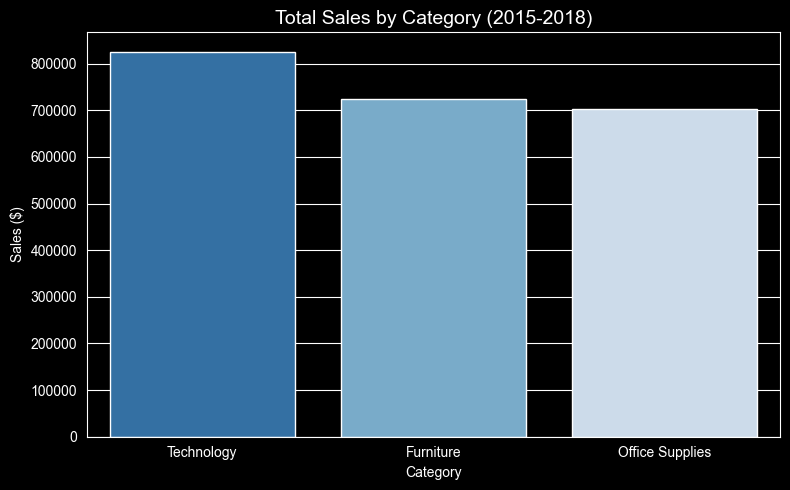

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64


In [4]:
# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_r')
plt.title('Total Sales by Category (2015-2018)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_category.png')
plt.show()

print(category_sales)

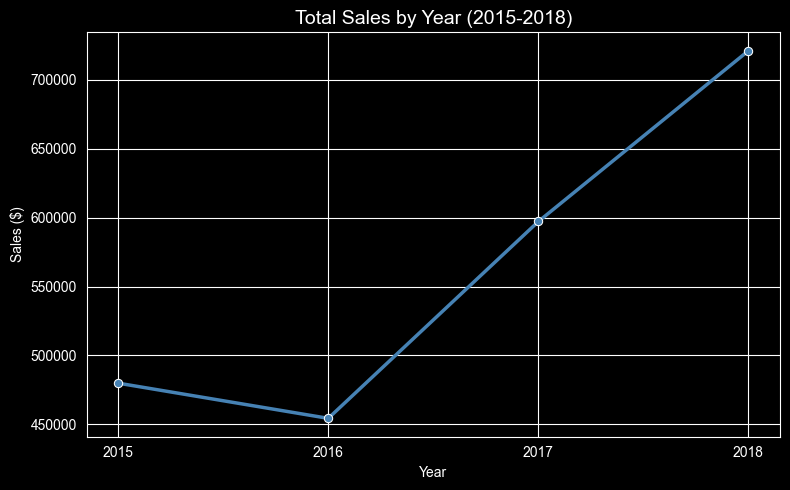

Year
2015    479856.2081
2016    454315.9054
2017    597225.4900
2018    721209.8092
Name: Sales, dtype: float64


In [5]:
# Sales trend by year
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8, 5))
sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker='o', color='steelblue', linewidth=2.5)
plt.title('Total Sales by Year (2015-2018)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Sales ($)')
plt.xticks([2015, 2016, 2017, 2018])
plt.tight_layout()
plt.savefig('sales_by_year.png')
plt.show()

print(yearly_sales)

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_10260\3564166672.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='viridis')


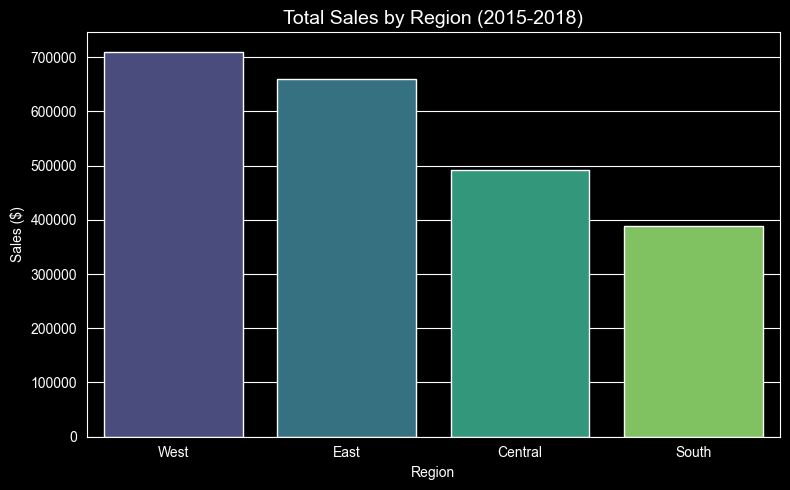

Region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [6]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='viridis')
plt.title('Total Sales by Region (2015-2018)', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.show()

print(region_sales)

In [7]:
# Export to Excel for dashboard
with pd.ExcelWriter('sales_dashboard.xlsx', engine='openpyxl') as writer:

    # Raw data
    df.to_excel(writer, sheet_name='Raw Data', index=False)

    # Sales by category
    category_sales.reset_index().to_excel(writer, sheet_name='By Category', index=False)

    # Sales by year
    yearly_sales.reset_index().to_excel(writer, sheet_name='By Year', index=False)

    # Sales by region
    region_sales.reset_index().to_excel(writer, sheet_name='By Region', index=False)

print("Excel file created!")

Excel file created!
